# Single Pile Sleeve Demo — Wave + Current

Demonstration of `VortexAmp` for one pile sleeve (D = 4.88 m) with oscillatory wave velocity superimposed on a steady current.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import SymLogNorm
from scipy import signal

from vortex_amp import (VortexAmp, compute_velocity_field,
                        compute_strouhal_number, compute_drag_coefficient)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

# Physical parameters
D = 4.88              # Cylinder diameter [m]
NU = 1.14e-6         # Kinematic viscosity [m²/s]

# Wave + current velocity profile
U_CURRENT = 0.55       # Steady current [m/s]
U_WAVE = 0.4          # Wave orbital velocity amplitude [m/s]
T_WAVE = 20.0         # Wave period [s]

def velocity_function(t):
    """Combined current + sinusoidal wave velocity."""
    return U_CURRENT + U_WAVE * np.sin(2 * np.pi * t / T_WAVE)

# Peak / mean / trough velocities
U_PEAK = U_CURRENT + U_WAVE
U_MEAN = U_CURRENT
U_TROUGH = U_CURRENT - U_WAVE  # negative = flow reversal

# Reynolds numbers at peak velocity (for reference)
RE_PEAK = U_PEAK * D / NU
RE_MEAN = U_MEAN * D / NU

# Keulegan-Carpenter number: KC = U_wave * T / D
KC = U_WAVE * T_WAVE / D

# Domain sizing (in diameters)
X_MIN, X_MAX = -5 * D, 40 * D
Y_MIN, Y_MAX = -5 * D,  5 * D

# Derived at peak velocity
ST = compute_strouhal_number(RE_PEAK)
CD = compute_drag_coefficient(RE_PEAK)
F_SHED = ST * U_PEAK / D
T_SHED = 1.0 / F_SHED

print(f'U_current = {U_CURRENT:.3f} m/s')
print(f'U_wave    = {U_WAVE:.3f} m/s  (T_wave = {T_WAVE:.1f} s)')
print(f'U_peak    = {U_PEAK:.3f} m/s')
print(f'U_trough  = {U_TROUGH:.3f} m/s')
print(f'KC        = {KC:.2f}')
print(f'Re_peak   = {RE_PEAK:.2e}')
print(f'Re_mean   = {RE_MEAN:.2e}')
print(f'St        = {ST:.3f}')
print(f'C_D       = {CD:.3f}')
print(f'f_shed    = {F_SHED:.4f} Hz')
print(f'T_shed    = {T_SHED:.3f} s (at peak)')

U_current = 0.550 m/s
U_wave    = 0.400 m/s  (T_wave = 20.0 s)
U_peak    = 0.950 m/s
U_trough  = 0.150 m/s
KC        = 1.64
Re_peak   = 4.07e+06
Re_mean   = 2.35e+06
St        = 0.200
C_D       = 1.023
f_shed    = 0.0389 Hz
T_shed    = 25.684 s (at peak)


In [2]:
# Cylinder and probe definitions
cylinders = [{'x': 0.0, 'y': 0.0, 'D': D}]

measurement_points = [
    ( 3 * D, 0.0),     # Near wake, centreline
    ( 8 * D, 0.0),     # Mid wake, centreline
    (20 * D, 0.0),     # Far wake, centreline
    ( 8 * D, 1.0 * D), # Mid wake, off-centre
]

# Simulation timing — run enough wave cycles to see the interaction
DT = 0.005
N_WAVE_CYCLES = 50
TOTAL_TIME = N_WAVE_CYCLES * T_WAVE
SAVE_INTERVAL = T_WAVE / 6   # snapshots per wave cycle
OUTPUT_DIR = 'output/demo_wave_current'

print(f'Total time   = {TOTAL_TIME:.1f} s  ({N_WAVE_CYCLES} wave cycles)')
print(f'Shed cycles  ~ {TOTAL_TIME/T_SHED:.0f} (at peak velocity)')
print(f'Steps        = {int(TOTAL_TIME/DT)}')
print(f'Save interval= {SAVE_INTERVAL:.3f} s')

Total time   = 1000.0 s  (50 wave cycles)
Shed cycles  ~ 39 (at peak velocity)
Steps        = 200000
Save interval= 3.333 s


In [3]:
# Run simulation
sim = VortexAmp(
    cylinders=cylinders,
    nu=NU,
    flow_angle_metocean=270.0,   # left -> right
    rotation_angle=0.0,
    x_removal=X_MAX + 2 * D,
    dt=DT,
    measurement_points=measurement_points,
    save_interval=SAVE_INTERVAL,
    sigma_max_factor=None,
    output_base_dir=OUTPUT_DIR,
)

results = sim.run(
    velocity_mode='function',
    velocity_function=velocity_function,
    total_time=TOTAL_TIME,
    output_dir=OUTPUT_DIR,
    U_current=U_CURRENT,
    U_wave_amp=U_WAVE,
    T_wave=T_WAVE,
)

sim.save_results('demo_wave_current_results.pkl')
print(f'Results shape: {results.shape}')

Output directory: output/demo_wave_current
Starting vortex method simulation...
  Reference velocity (Uc+Um) = 0.950 m/s
  Reference Reynolds number  = 4.07e+06
  Strouhal number            = 0.200
  Shedding period (fixed)    = 25.684 s
  Keulegan-Carpenter KC      = 1.64
  KC shedding threshold      = 4.0



Simulating: 100%|██████████| 200000/200000 [00:50<00:00, 3949.04step/s]


Simulation complete. Total vortices in domain: 30
Results saved to output/demo_wave_current\demo_wave_current_results.pkl
Results shape: (200000, 18)


## Velocity Field

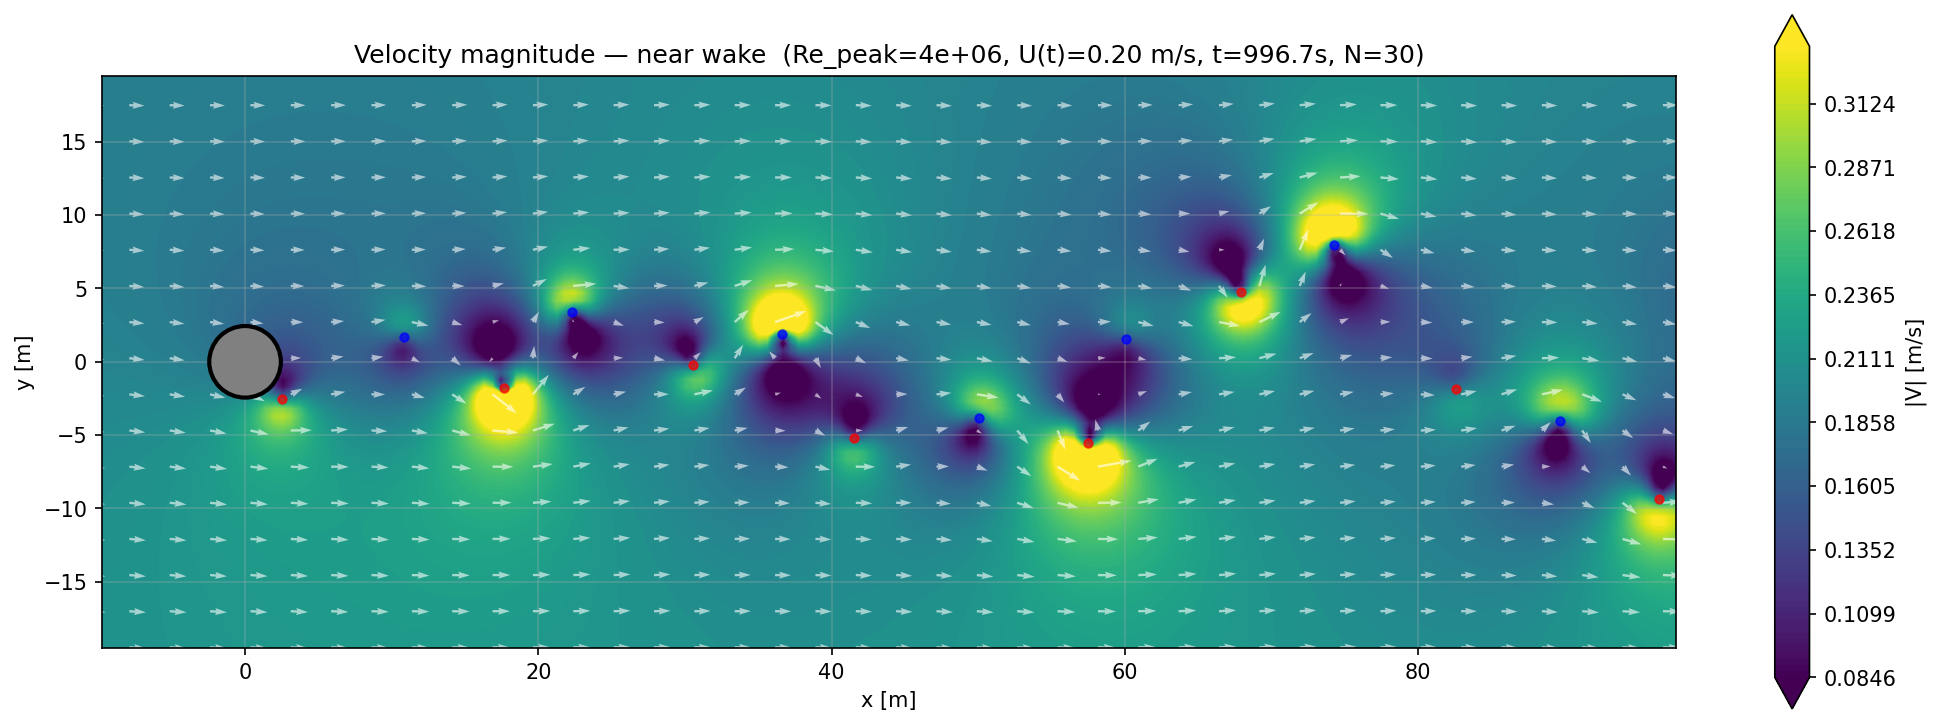

In [4]:
# Pick last saved snapshot
snap_idx = results[results['vortex_field'].notna()].index[-1]
vortex_field = results.loc[snap_idx, 'vortex_field']
snap_time = results.loc[snap_idx, 'time']
U_snap = results.loc[snap_idx, 'U_inf']  # instantaneous velocity at snapshot

# Build velocity on regular grid
nx, ny = 400, 100
gx = np.linspace(X_MIN, X_MAX, nx)
gy = np.linspace(Y_MIN, Y_MAX, ny)
X, Y = np.meshgrid(gx, gy)

U, V = compute_velocity_field(X, Y, vortex_field, U_snap, flow_angle=0.0)
vel_mag = np.sqrt(U**2 + V**2)

# --- Near-wake velocity field ---
fig, ax = plt.subplots(figsize=(14, 5))

# Use tight data range so the colormap resolves actual variations
vmin = np.percentile(vel_mag, 1)
vmax = np.percentile(vel_mag, 99)
cf = ax.contourf(X, Y, vel_mag, levels=np.linspace(vmin, vmax, 100),
                 cmap='viridis', extend='both')
plt.colorbar(cf, ax=ax, label='|V| [m/s]')

skip = 5
ax.quiver(X[::skip, ::skip], Y[::skip, ::skip],
          U[::skip, ::skip], V[::skip, ::skip],
          color='white', alpha=0.6, scale=vmax * 60, width=0.0015)

# Plot vortex positions
for v in vortex_field:
    color = 'red' if v['gamma'] > 0 else 'blue'
    ax.plot(v['x'], v['y'], 'o', color=color, markersize=4, alpha=0.7)

ax.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax.set_xlim(-2 * D, 20 * D)
ax.set_ylim(-4 * D, 4 * D)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Velocity magnitude — near wake  (Re_peak={RE_PEAK:.0e}, U(t)={U_snap:.2f} m/s, t={snap_time:.1f}s, N={len(vortex_field)})')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/velocity_field_nearwake.png', dpi=300, bbox_inches='tight')
plt.show()

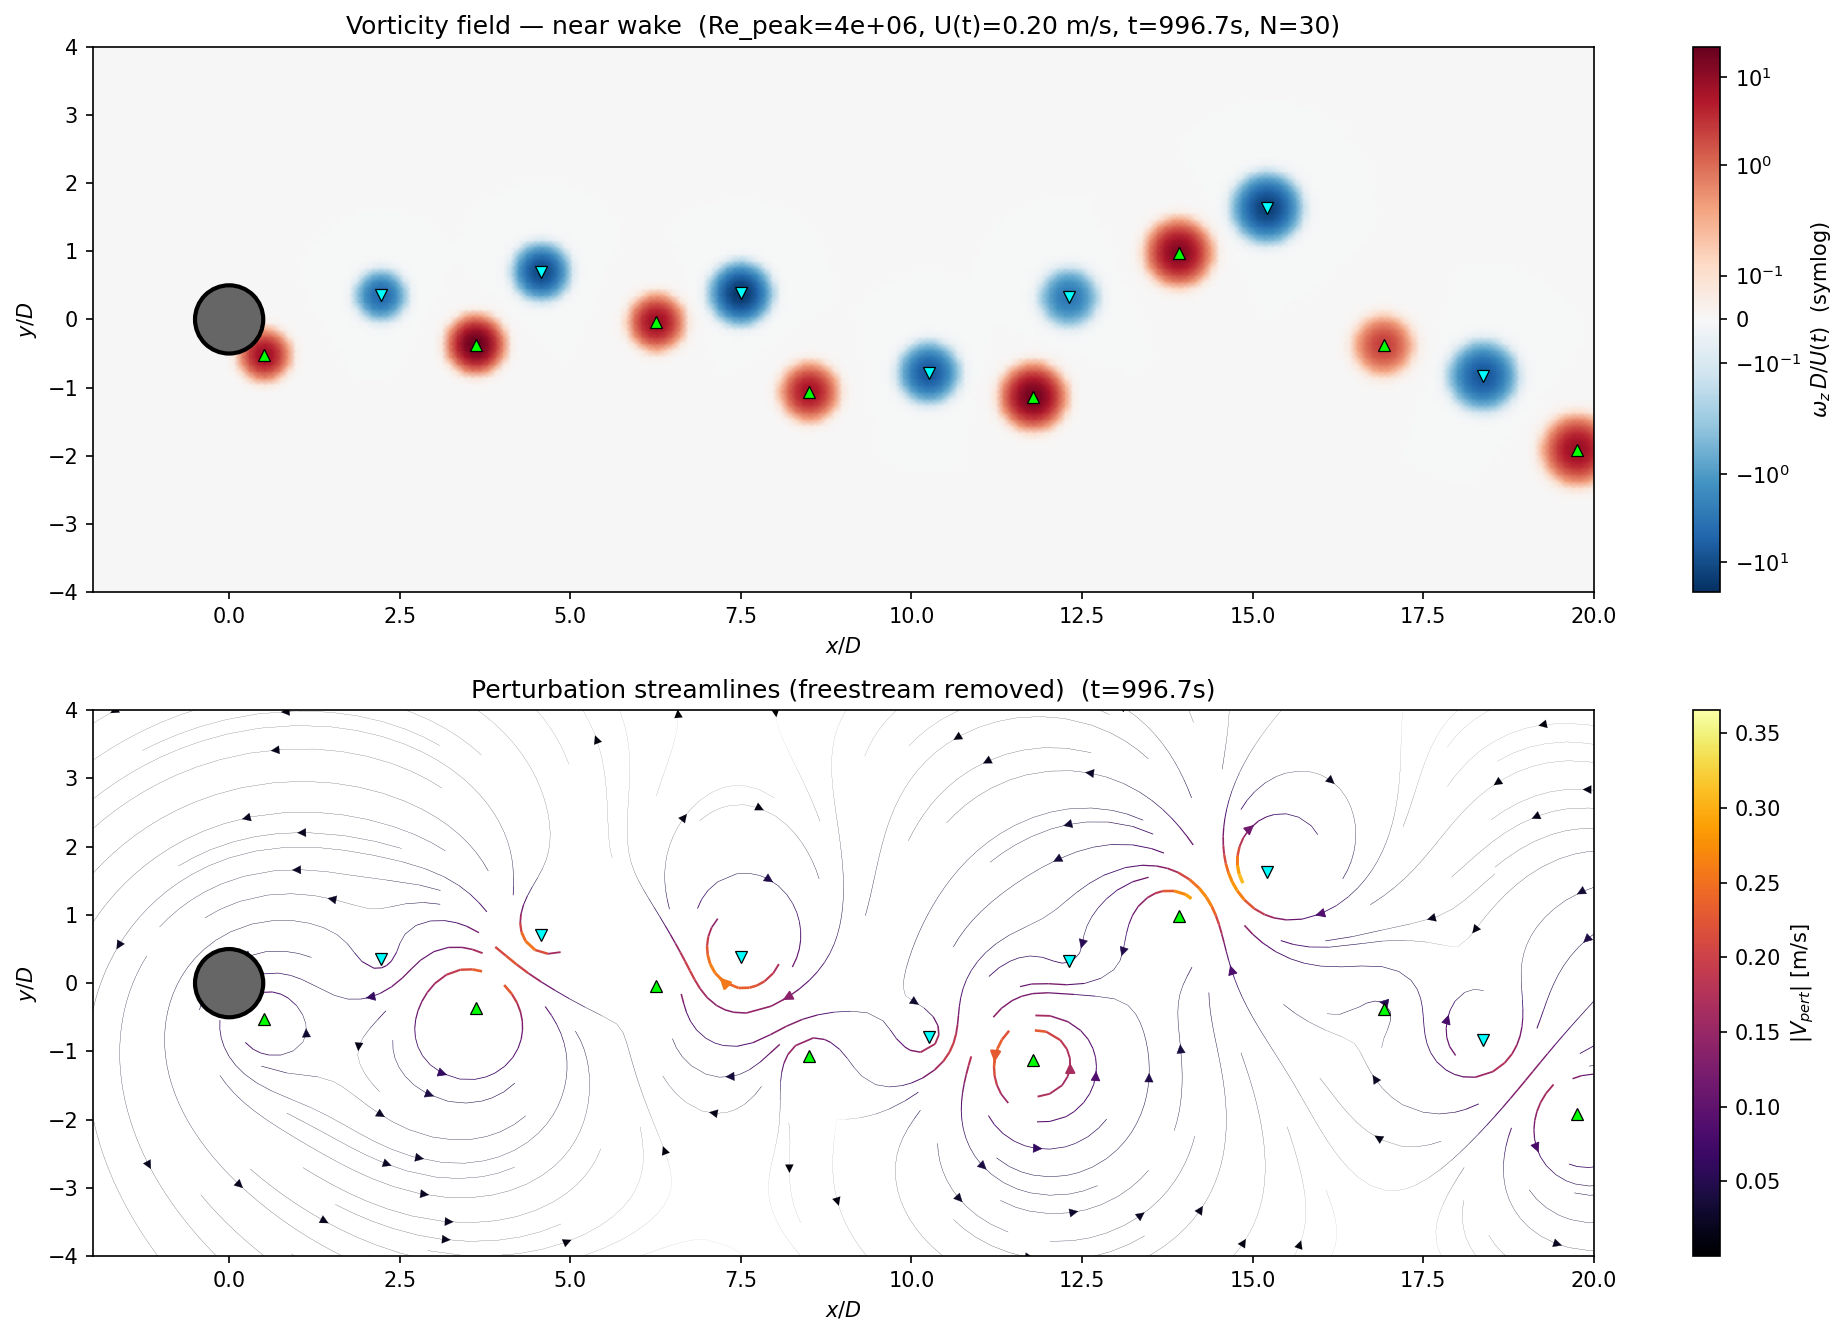

In [5]:
# --- Near-wake vorticity + perturbation streamlines ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

# --- Top: vorticity field (near-wake zoom) with SymLogNorm ---
omega = np.zeros_like(X)
for v in vortex_field:
    r2 = (X - v['x'])**2 + (Y - v['y'])**2
    sigma2 = v['sigma']**2
    omega += (v['gamma'] / (np.pi * sigma2)) * np.exp(-r2 / sigma2)

omega_star = omega * D / U_snap
omega_lim = np.max(np.abs(omega_star))

linthresh = 0.01 * omega_lim
norm = SymLogNorm(linthresh=linthresh, vmin=-omega_lim, vmax=omega_lim, base=10)
pcm = ax1.pcolormesh(X / D, Y / D, omega_star, norm=norm,
                      cmap='RdBu_r', shading='gouraud')
plt.colorbar(pcm, ax=ax1, label=r'$\omega_z \, D / U(t)$  (symlog)')

for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    ax1.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=6,
             markeredgecolor='black', markeredgewidth=0.6, zorder=10)

ax1.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=2, zorder=10))
ax1.set_xlim(-2, 20)
ax1.set_ylim(-4, 4)
ax1.set_xlabel('$x / D$')
ax1.set_ylabel('$y / D$')
ax1.set_title(f'Vorticity field — near wake  (Re_peak={RE_PEAK:.0e}, U(t)={U_snap:.2f} m/s, t={snap_time:.1f}s, N={len(vortex_field)})')
ax1.set_aspect('equal')

# --- Bottom: perturbation streamlines ---
U_pert = U - U_snap
V_pert = V

speed_pert = np.sqrt(U_pert**2 + V_pert**2)
lw = 2 * speed_pert / speed_pert.max()

strm = ax2.streamplot(gx / D, gy / D, U_pert, V_pert,
                       color=speed_pert, cmap='inferno', linewidth=lw,
                       density=2.5, arrowsize=1.0)
plt.colorbar(strm.lines, ax=ax2, label='$|V_{pert}|$ [m/s]')

for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    ax2.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=6,
             markeredgecolor='black', markeredgewidth=0.6, zorder=10)

ax2.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=2, zorder=10))
ax2.set_xlim(-2, 20)
ax2.set_ylim(-4, 4)
ax2.set_xlabel('$x / D$')
ax2.set_ylabel('$y / D$')
ax2.set_title(f'Perturbation streamlines (freestream removed)  (t={snap_time:.1f}s)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/nearwake_vorticity_streamlines.png', dpi=300, bbox_inches='tight')
plt.show()

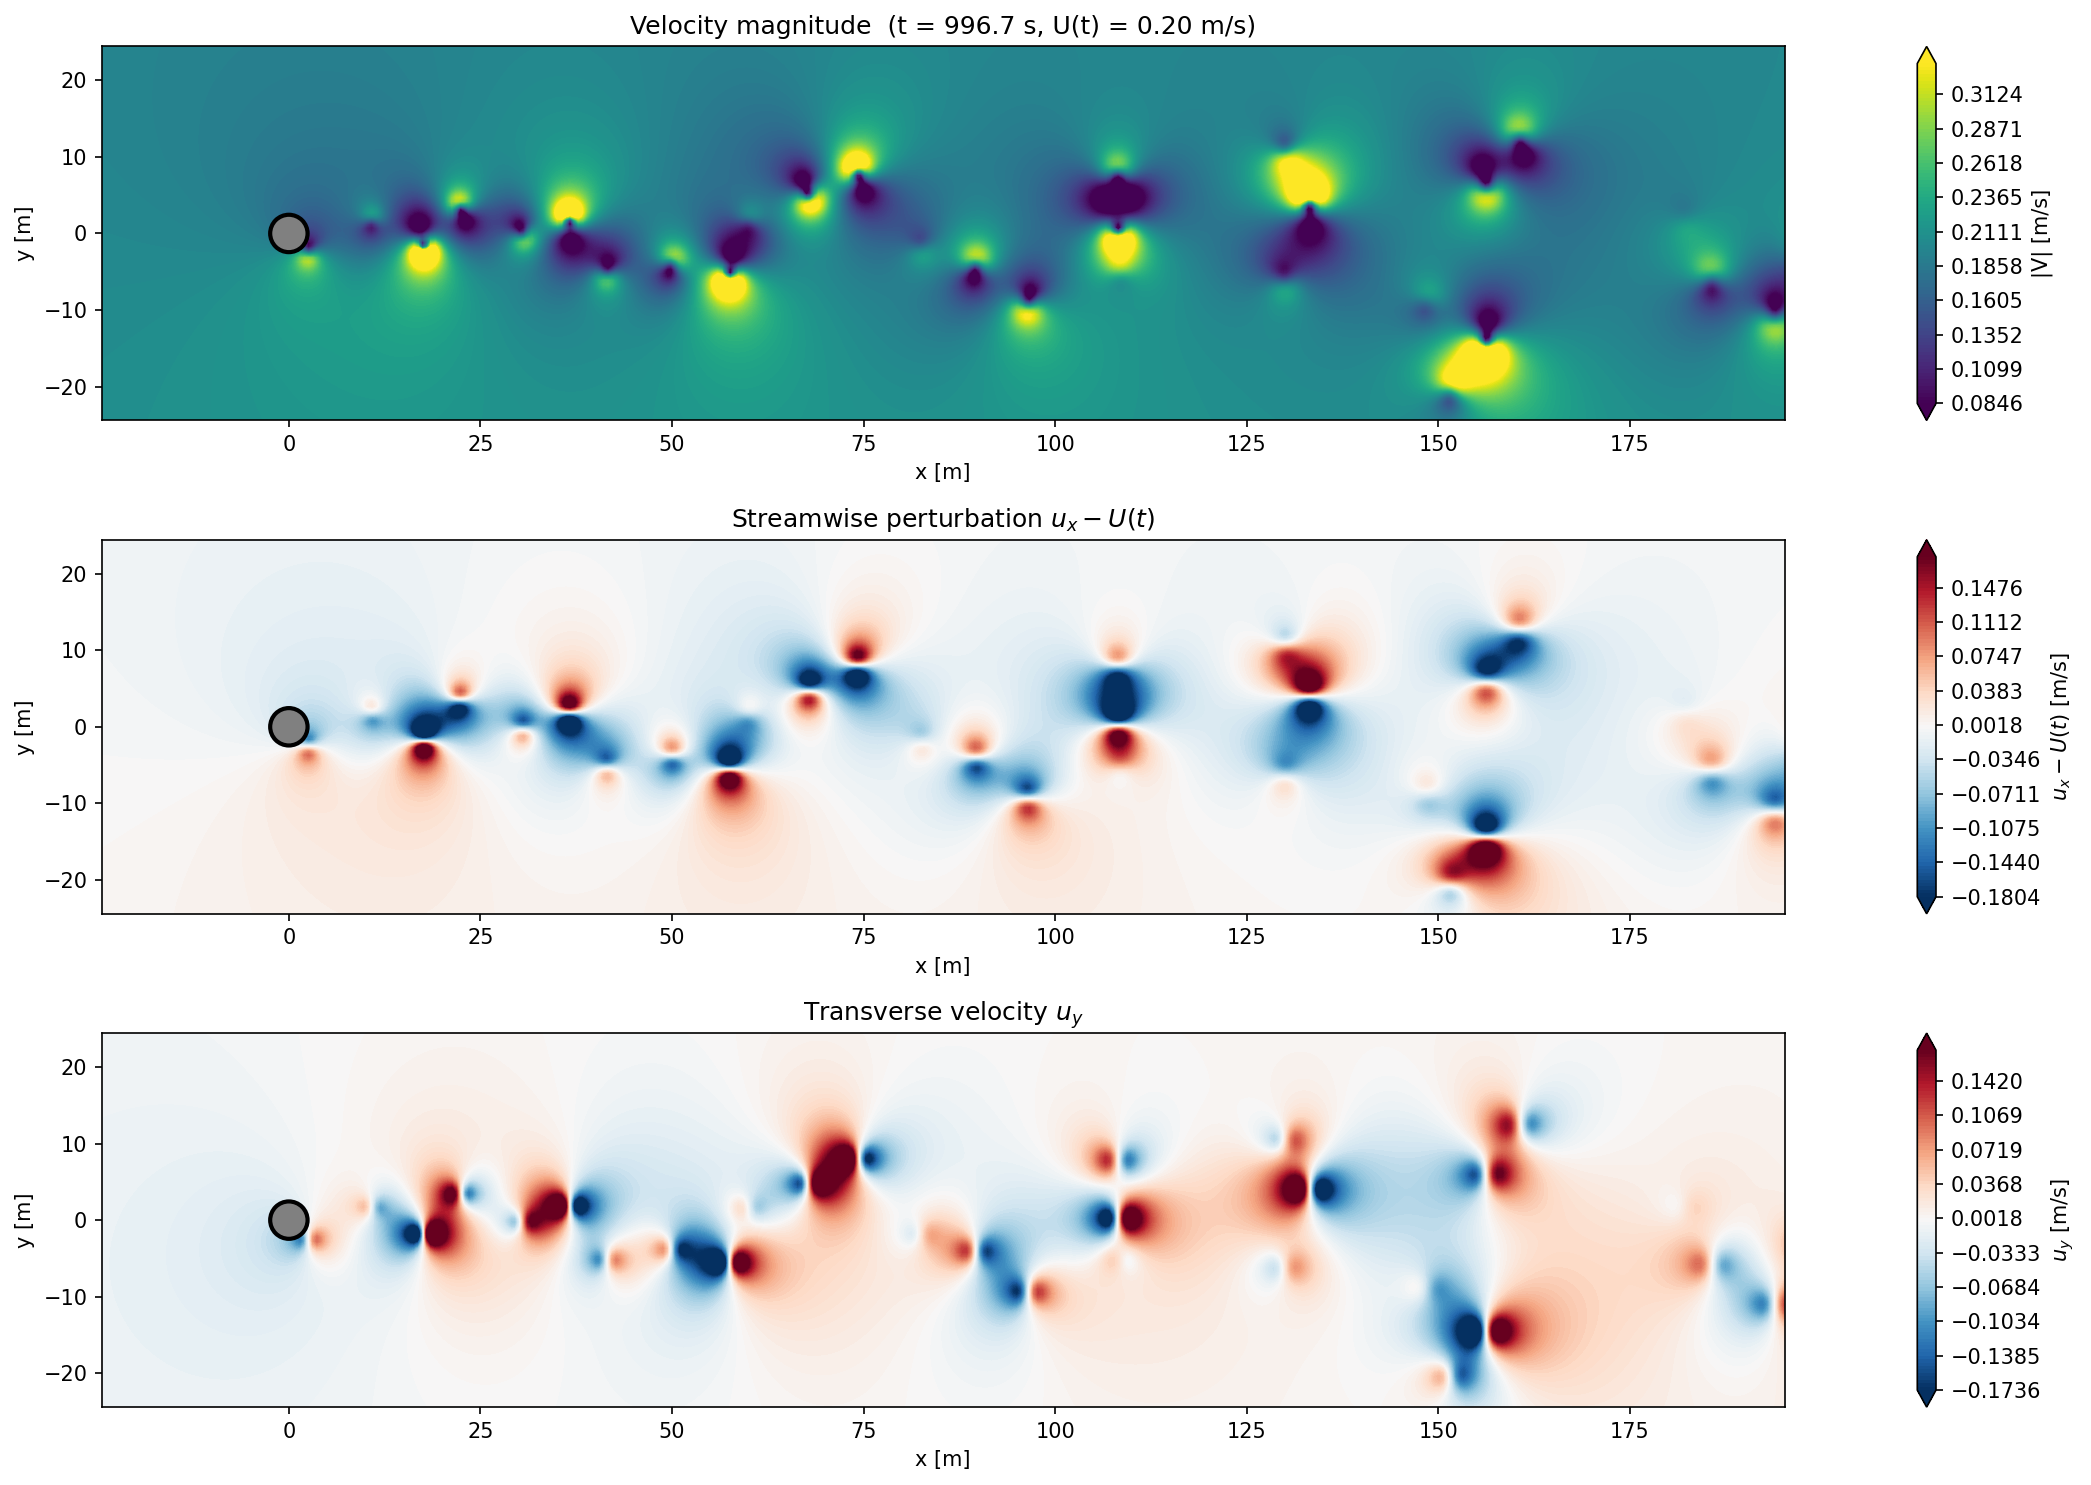

In [6]:
# --- Full-domain velocity components (|V|, u', v) ---
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

# Velocity magnitude — tight range
ax1 = axes[0]
vmin = np.percentile(vel_mag, 1)
vmax = np.percentile(vel_mag, 99)
cf1 = ax1.contourf(X, Y, vel_mag, levels=np.linspace(vmin, vmax, 100),
                   cmap='viridis', extend='both')
plt.colorbar(cf1, ax=ax1, label='|V| [m/s]')
ax1.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax1.set_xlim(X_MIN, X_MAX)
ax1.set_ylim(Y_MIN, Y_MAX)
ax1.set_title(f'Velocity magnitude  (t = {snap_time:.1f} s, U(t) = {U_snap:.2f} m/s)')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_aspect('equal')

# u-perturbation (u - U(t)) so diverging colormap centres on zero
U_prime = U - U_snap
ax2 = axes[1]
u_lim = np.percentile(np.abs(U_prime), 99)
cf2 = ax2.contourf(X, Y, U_prime, levels=np.linspace(-u_lim, u_lim, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=ax2, label="$u_x - U(t)$ [m/s]")
ax2.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax2.set_xlim(X_MIN, X_MAX)
ax2.set_ylim(Y_MIN, Y_MAX)
ax2.set_title("Streamwise perturbation $u_x - U(t)$")
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_aspect('equal')

# v-component (already centred at zero)
ax3 = axes[2]
v_lim = np.percentile(np.abs(V), 99)
cf3 = ax3.contourf(X, Y, V, levels=np.linspace(-v_lim, v_lim, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf3, ax=ax3, label='$u_y$ [m/s]')
ax3.add_patch(Circle((0, 0), D / 2, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax3.set_xlim(X_MIN, X_MAX)
ax3.set_ylim(Y_MIN, Y_MAX)
ax3.set_title('Transverse velocity $u_y$')
ax3.set_xlabel('x [m]')
ax3.set_ylabel('y [m]')
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/velocity_components.png', dpi=300, bbox_inches='tight')
plt.show()

## Flow Amplification Field

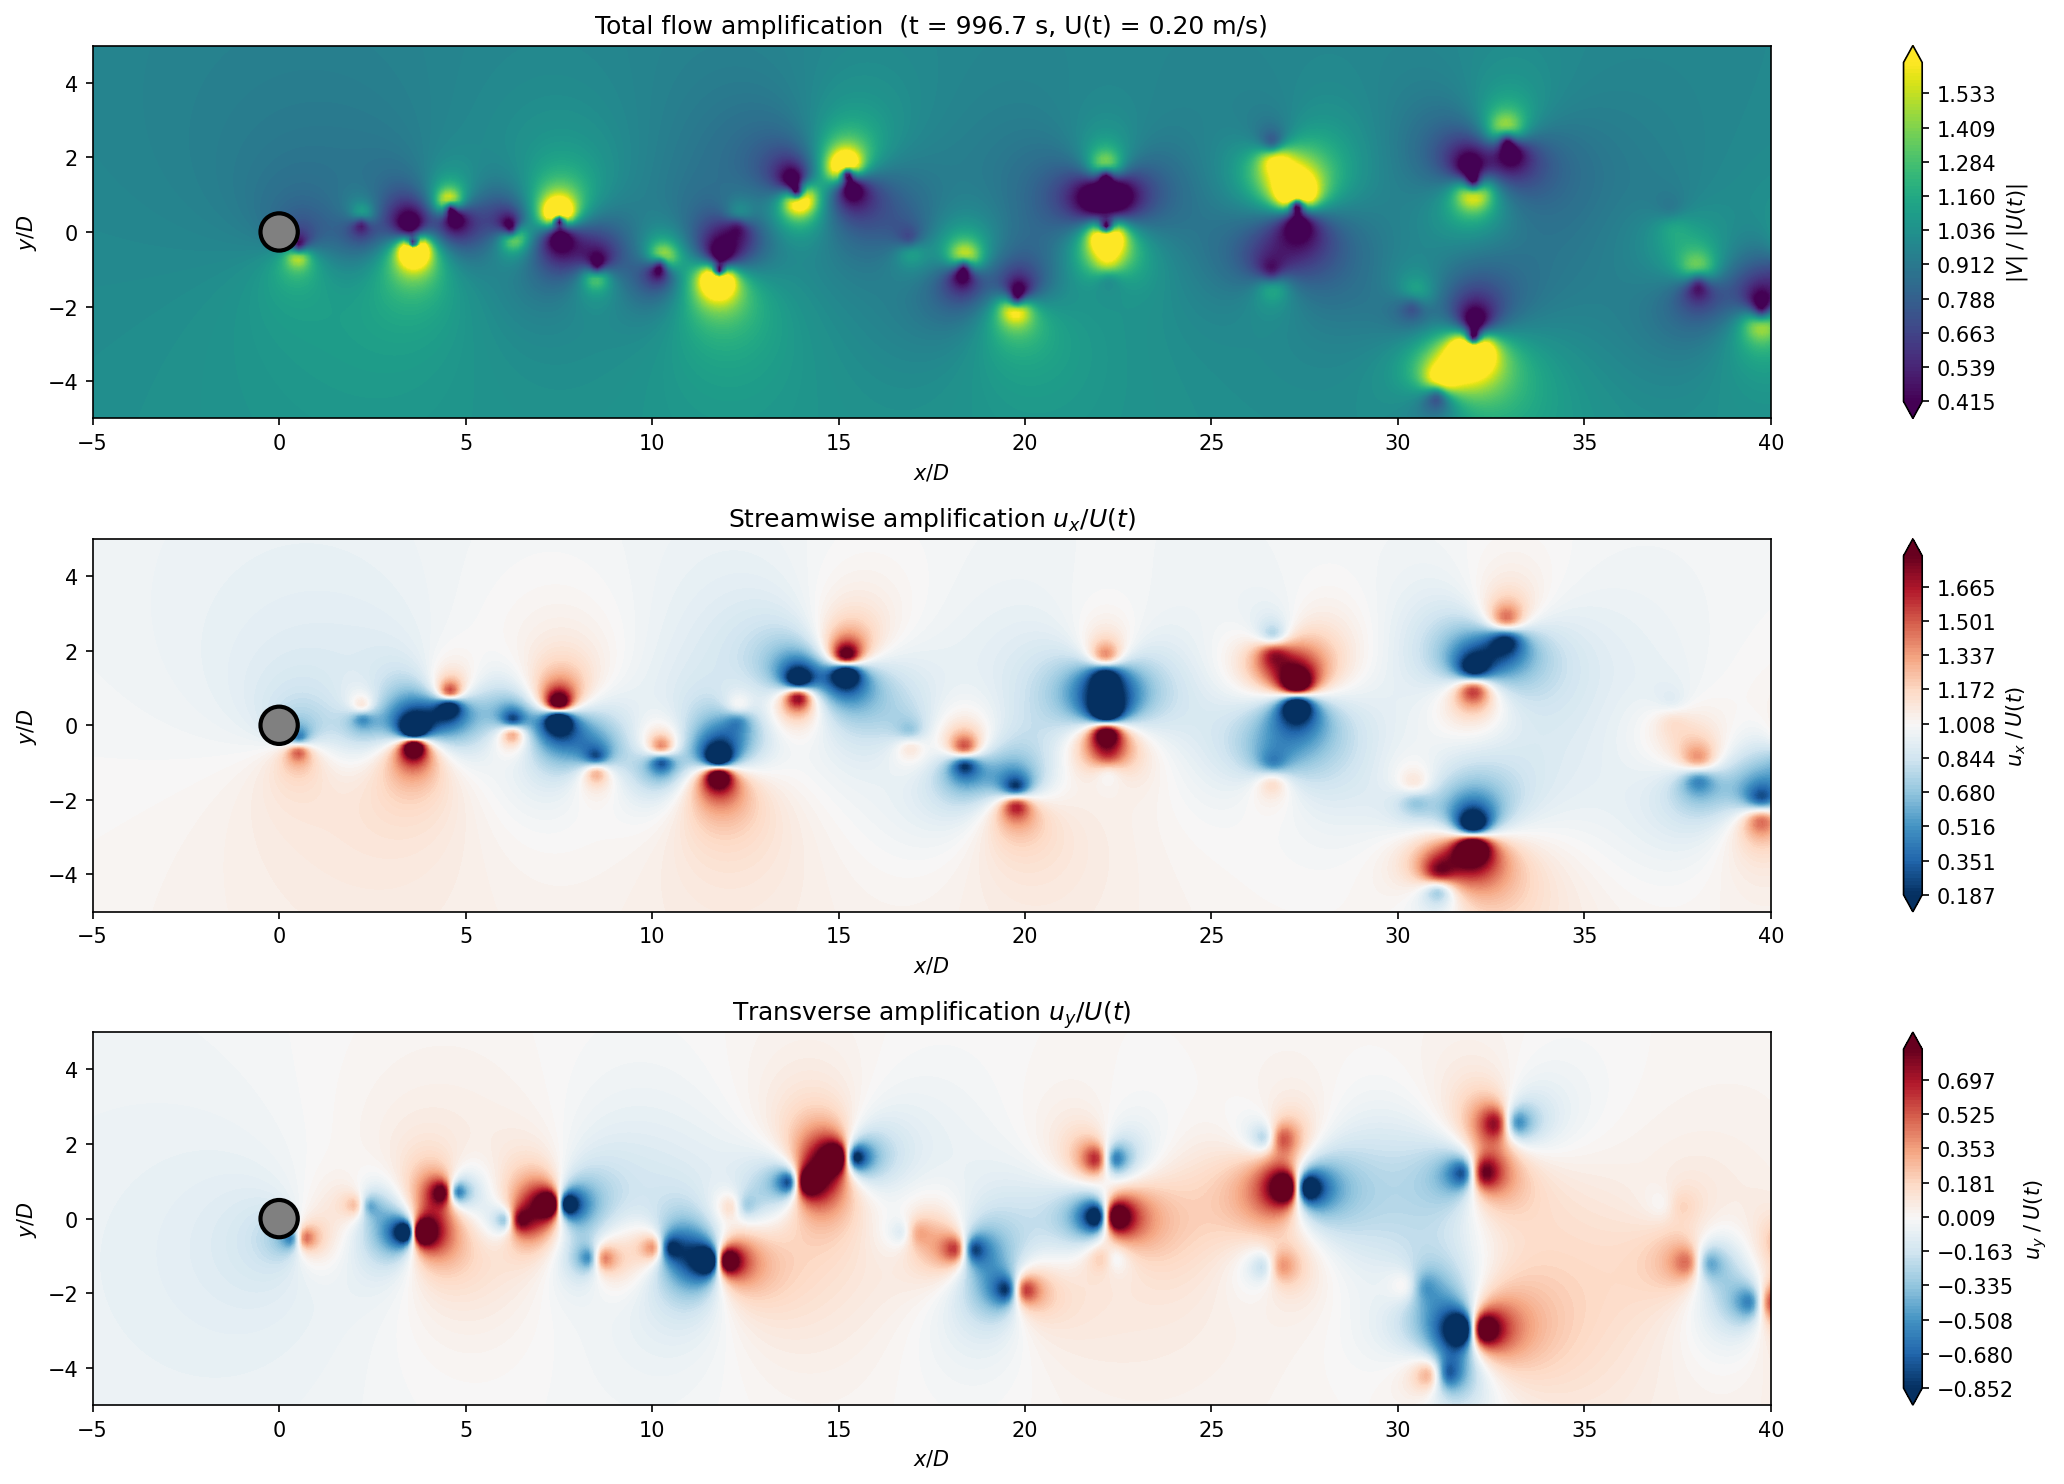

In [7]:
# --- Flow amplification: local velocity / freestream velocity ---
# Amplification = 1.0 means undisturbed freestream; >1 = acceleration; <1 = deceleration
amp_total = vel_mag / abs(U_snap)
amp_x = U / U_snap
amp_y = V / U_snap  # freestream is purely x, so V/U_snap gives the y-amplification

fig, axes = plt.subplots(3, 1, figsize=(18, 10))

# Total amplification |V|/|U(t)|
ax1 = axes[0]
amp_min = np.percentile(amp_total, 1)
amp_max = np.percentile(amp_total, 99)
cf1 = ax1.contourf(X / D, Y / D, amp_total, levels=np.linspace(amp_min, amp_max, 100),
                   cmap='viridis', extend='both')
plt.colorbar(cf1, ax=ax1, label=r'$|V| \; / \; |U(t)|$')
ax1.add_patch(Circle((0, 0), 0.5, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax1.set_xlim(X_MIN / D, X_MAX / D)
ax1.set_ylim(Y_MIN / D, Y_MAX / D)
ax1.set_title(f'Total flow amplification  (t = {snap_time:.1f} s, U(t) = {U_snap:.2f} m/s)')
ax1.set_xlabel('$x / D$')
ax1.set_ylabel('$y / D$')
ax1.set_aspect('equal')

# Streamwise amplification u_x / U(t) — diverging around 1.0
ax2 = axes[1]
amp_x_dev = np.max(np.abs(np.percentile(amp_x, [1, 99]) - 1.0))
cf2 = ax2.contourf(X / D, Y / D, amp_x, levels=np.linspace(1.0 - amp_x_dev, 1.0 + amp_x_dev, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=ax2, label=r'$u_x \; / \; U(t)$')
ax2.add_patch(Circle((0, 0), 0.5, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax2.set_xlim(X_MIN / D, X_MAX / D)
ax2.set_ylim(Y_MIN / D, Y_MAX / D)
ax2.set_title('Streamwise amplification $u_x / U(t)$')
ax2.set_xlabel('$x / D$')
ax2.set_ylabel('$y / D$')
ax2.set_aspect('equal')

# Transverse amplification u_y / U(t) — diverging around 0.0
ax3 = axes[2]
amp_y_lim = np.percentile(np.abs(amp_y), 99)
cf3 = ax3.contourf(X / D, Y / D, amp_y, levels=np.linspace(-amp_y_lim, amp_y_lim, 100),
                   cmap='RdBu_r', extend='both')
plt.colorbar(cf3, ax=ax3, label=r'$u_y \; / \; U(t)$')
ax3.add_patch(Circle((0, 0), 0.5, color='gray', fill=True, ec='k', lw=2, zorder=10))
ax3.set_xlim(X_MIN / D, X_MAX / D)
ax3.set_ylim(Y_MIN / D, Y_MAX / D)
ax3.set_title('Transverse amplification $u_y / U(t)$')
ax3.set_xlabel('$x / D$')
ax3.set_ylabel('$y / D$')
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/flow_amplification.png', dpi=300, bbox_inches='tight')
plt.show()

## Probe Locations

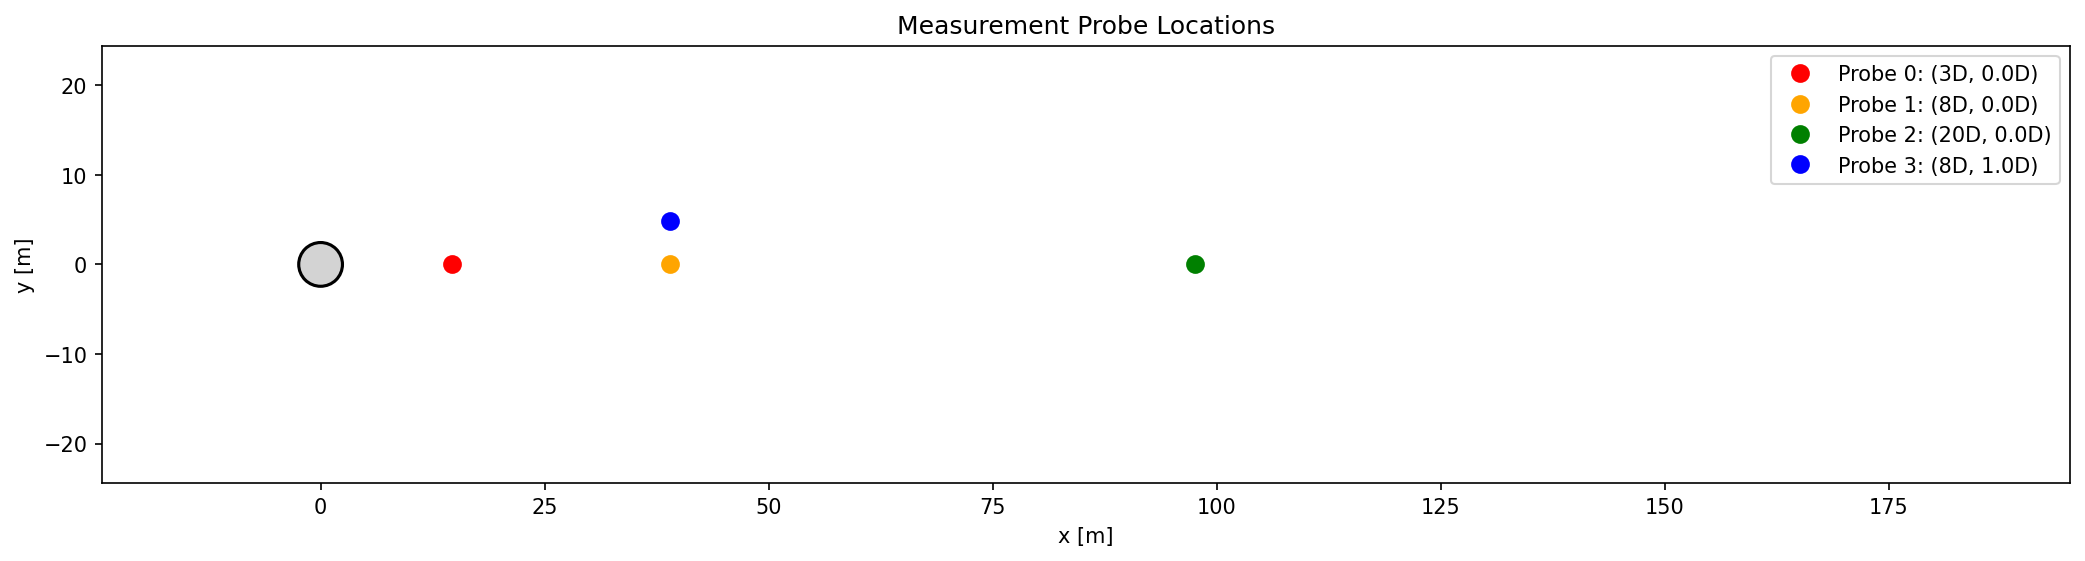

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.add_patch(Circle((0, 0), D / 2, color='lightgray', ec='k', lw=1.5, zorder=5))

colors = ['red', 'orange', 'green', 'blue']
for i, (px, py) in enumerate(measurement_points):
    ax.plot(px, py, 'o', color=colors[i], ms=8, zorder=6,
            label=f'Probe {i}: ({px/D:.0f}D, {py/D:.1f}D)')

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Measurement Probe Locations')
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/probe_locations.png', bbox_inches='tight')
plt.show()

## Input Velocity & Probe Time Series

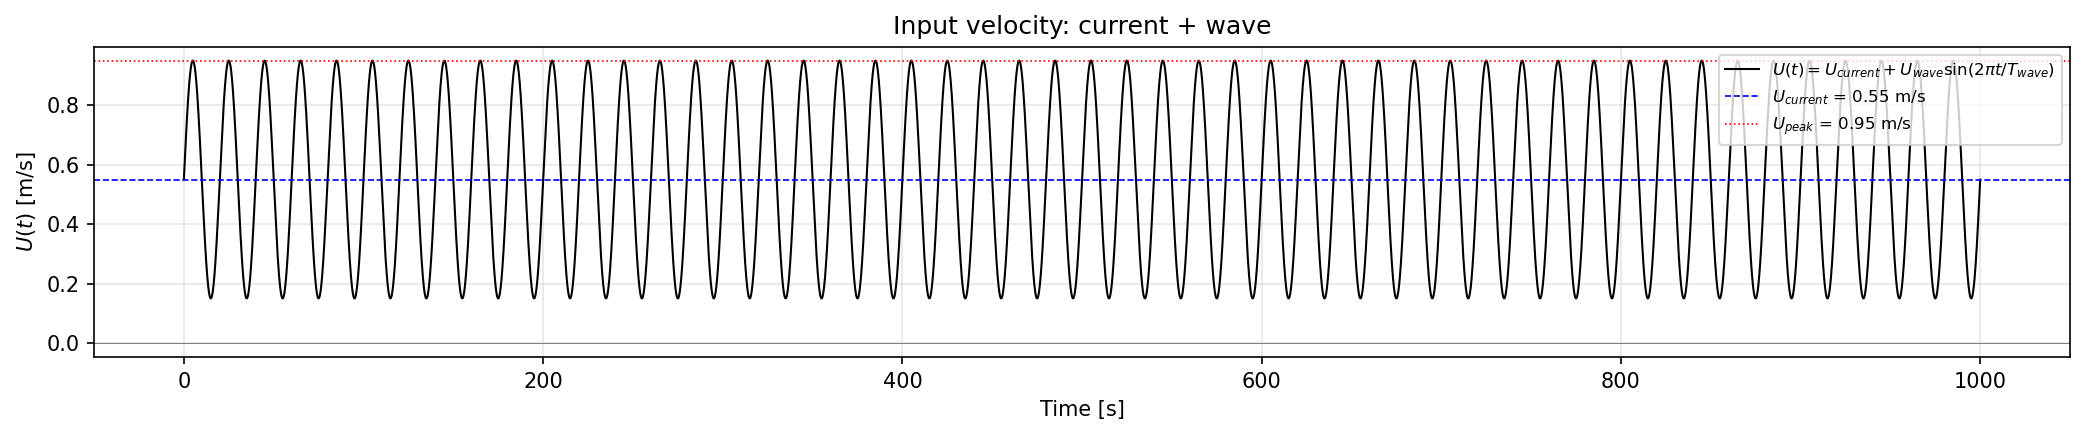

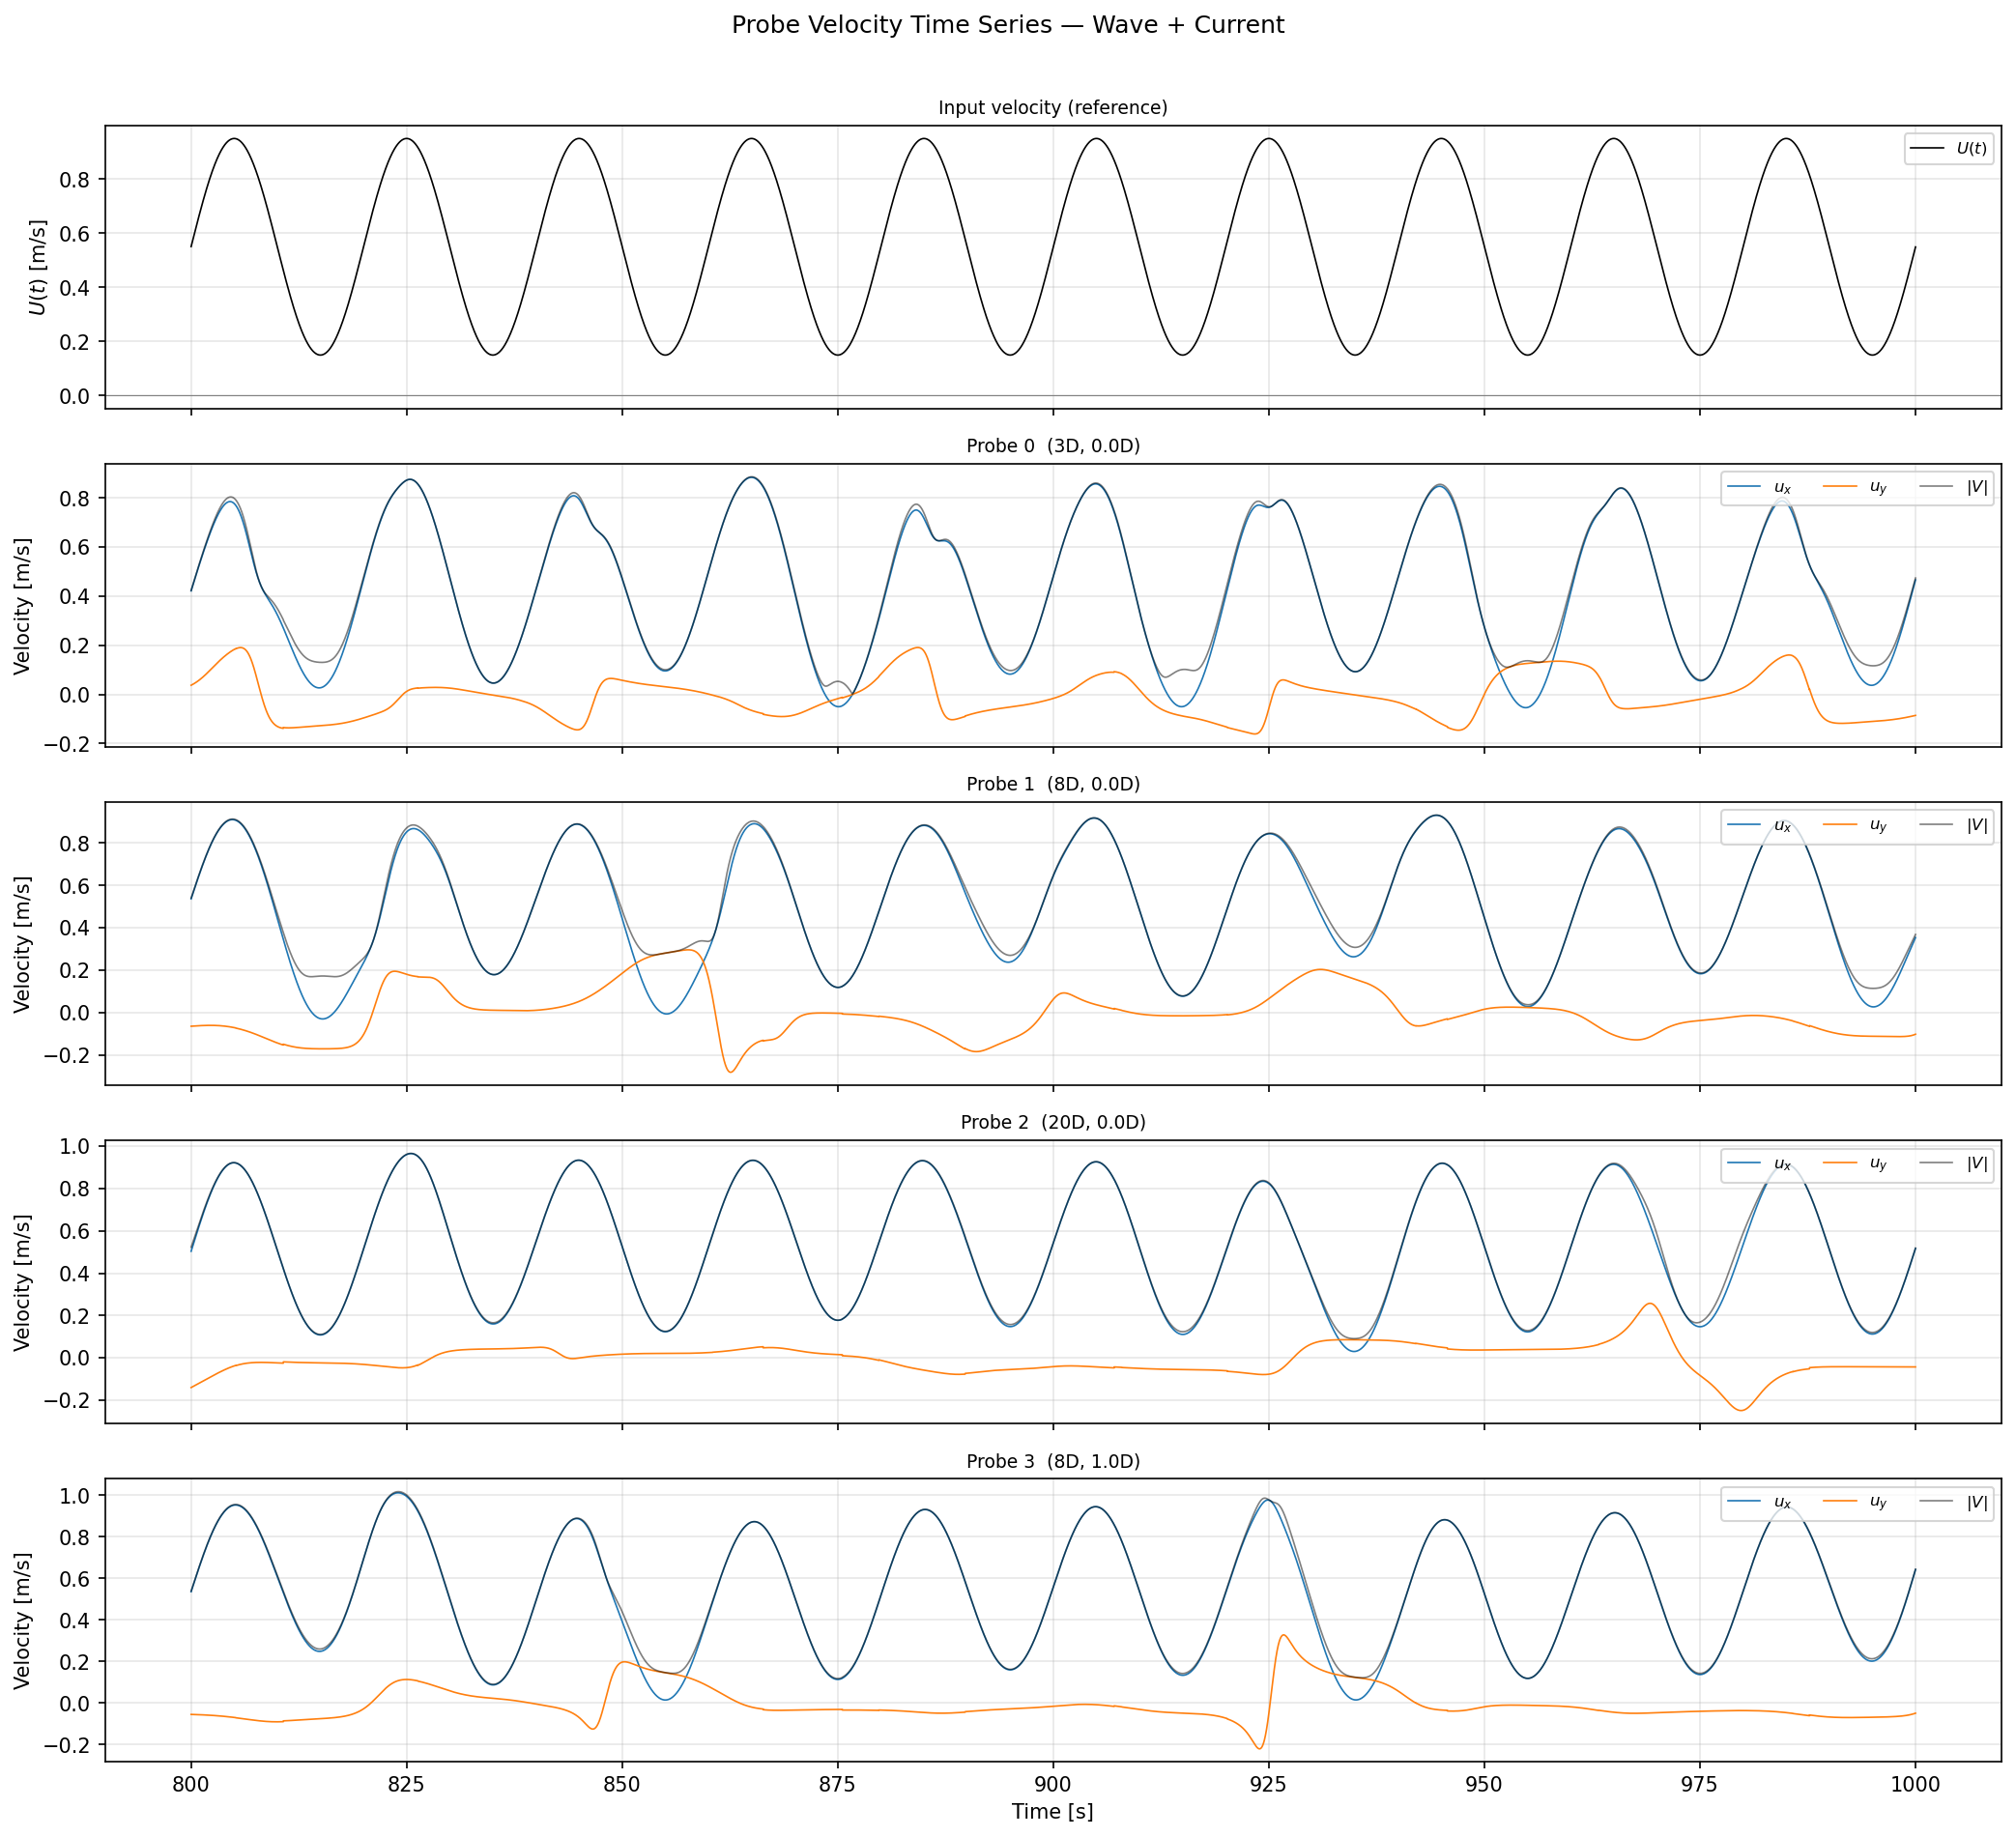

In [9]:
time_arr = results['time'].values
u_inf_arr = results['U_inf'].values

# --- Input velocity profile ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(time_arr, u_inf_arr, 'k-', lw=1.0, label='$U(t) = U_{current} + U_{wave} \\sin(2\\pi t / T_{wave})$')
ax.axhline(U_CURRENT, color='blue', ls='--', lw=0.8, label=f'$U_{{current}}$ = {U_CURRENT} m/s')
ax.axhline(U_PEAK, color='red', ls=':', lw=0.8, label=f'$U_{{peak}}$ = {round(U_PEAK, 2)} m/s')
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('$U(t)$ [m/s]')
ax.set_title('Input velocity: current + wave')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/input_velocity.png', bbox_inches='tight')
plt.show()

# --- Probe velocity time series (last 10 wave cycles) ---
t_start = max(0, TOTAL_TIME - 10 * T_WAVE)
mask = time_arr >= t_start

fig, axes = plt.subplots(len(measurement_points) + 1, 1,
                         figsize=(14, 2.5 * (len(measurement_points) + 1)), sharex=True)

# Top panel: input velocity for reference
axes[0].plot(time_arr[mask], u_inf_arr[mask], 'k-', lw=0.8, label='$U(t)$')
axes[0].axhline(0, color='gray', ls='-', lw=0.5)
axes[0].set_ylabel('$U(t)$ [m/s]')
axes[0].set_title('Input velocity (reference)', fontsize=9)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

for i, (px, py) in enumerate(measurement_points):
    ax = axes[i + 1]
    ux = results[f'probe_{i}_ux'].values[mask]
    uy = results[f'probe_{i}_uy'].values[mask]
    vmag = results[f'probe_{i}_vmag'].values[mask]

    ax.plot(time_arr[mask], ux,   lw=0.8, label='$u_x$')
    ax.plot(time_arr[mask], uy,   lw=0.8, label='$u_y$')
    ax.plot(time_arr[mask], vmag, lw=0.8, label='$|V|$', color='k', alpha=0.5)

    ax.set_ylabel('Velocity [m/s]')
    ax.set_title(f'Probe {i}  ({px/D:.0f}D, {py/D:.1f}D)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('Probe Velocity Time Series — Wave + Current', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/probe_velocities.png', bbox_inches='tight')
plt.show()

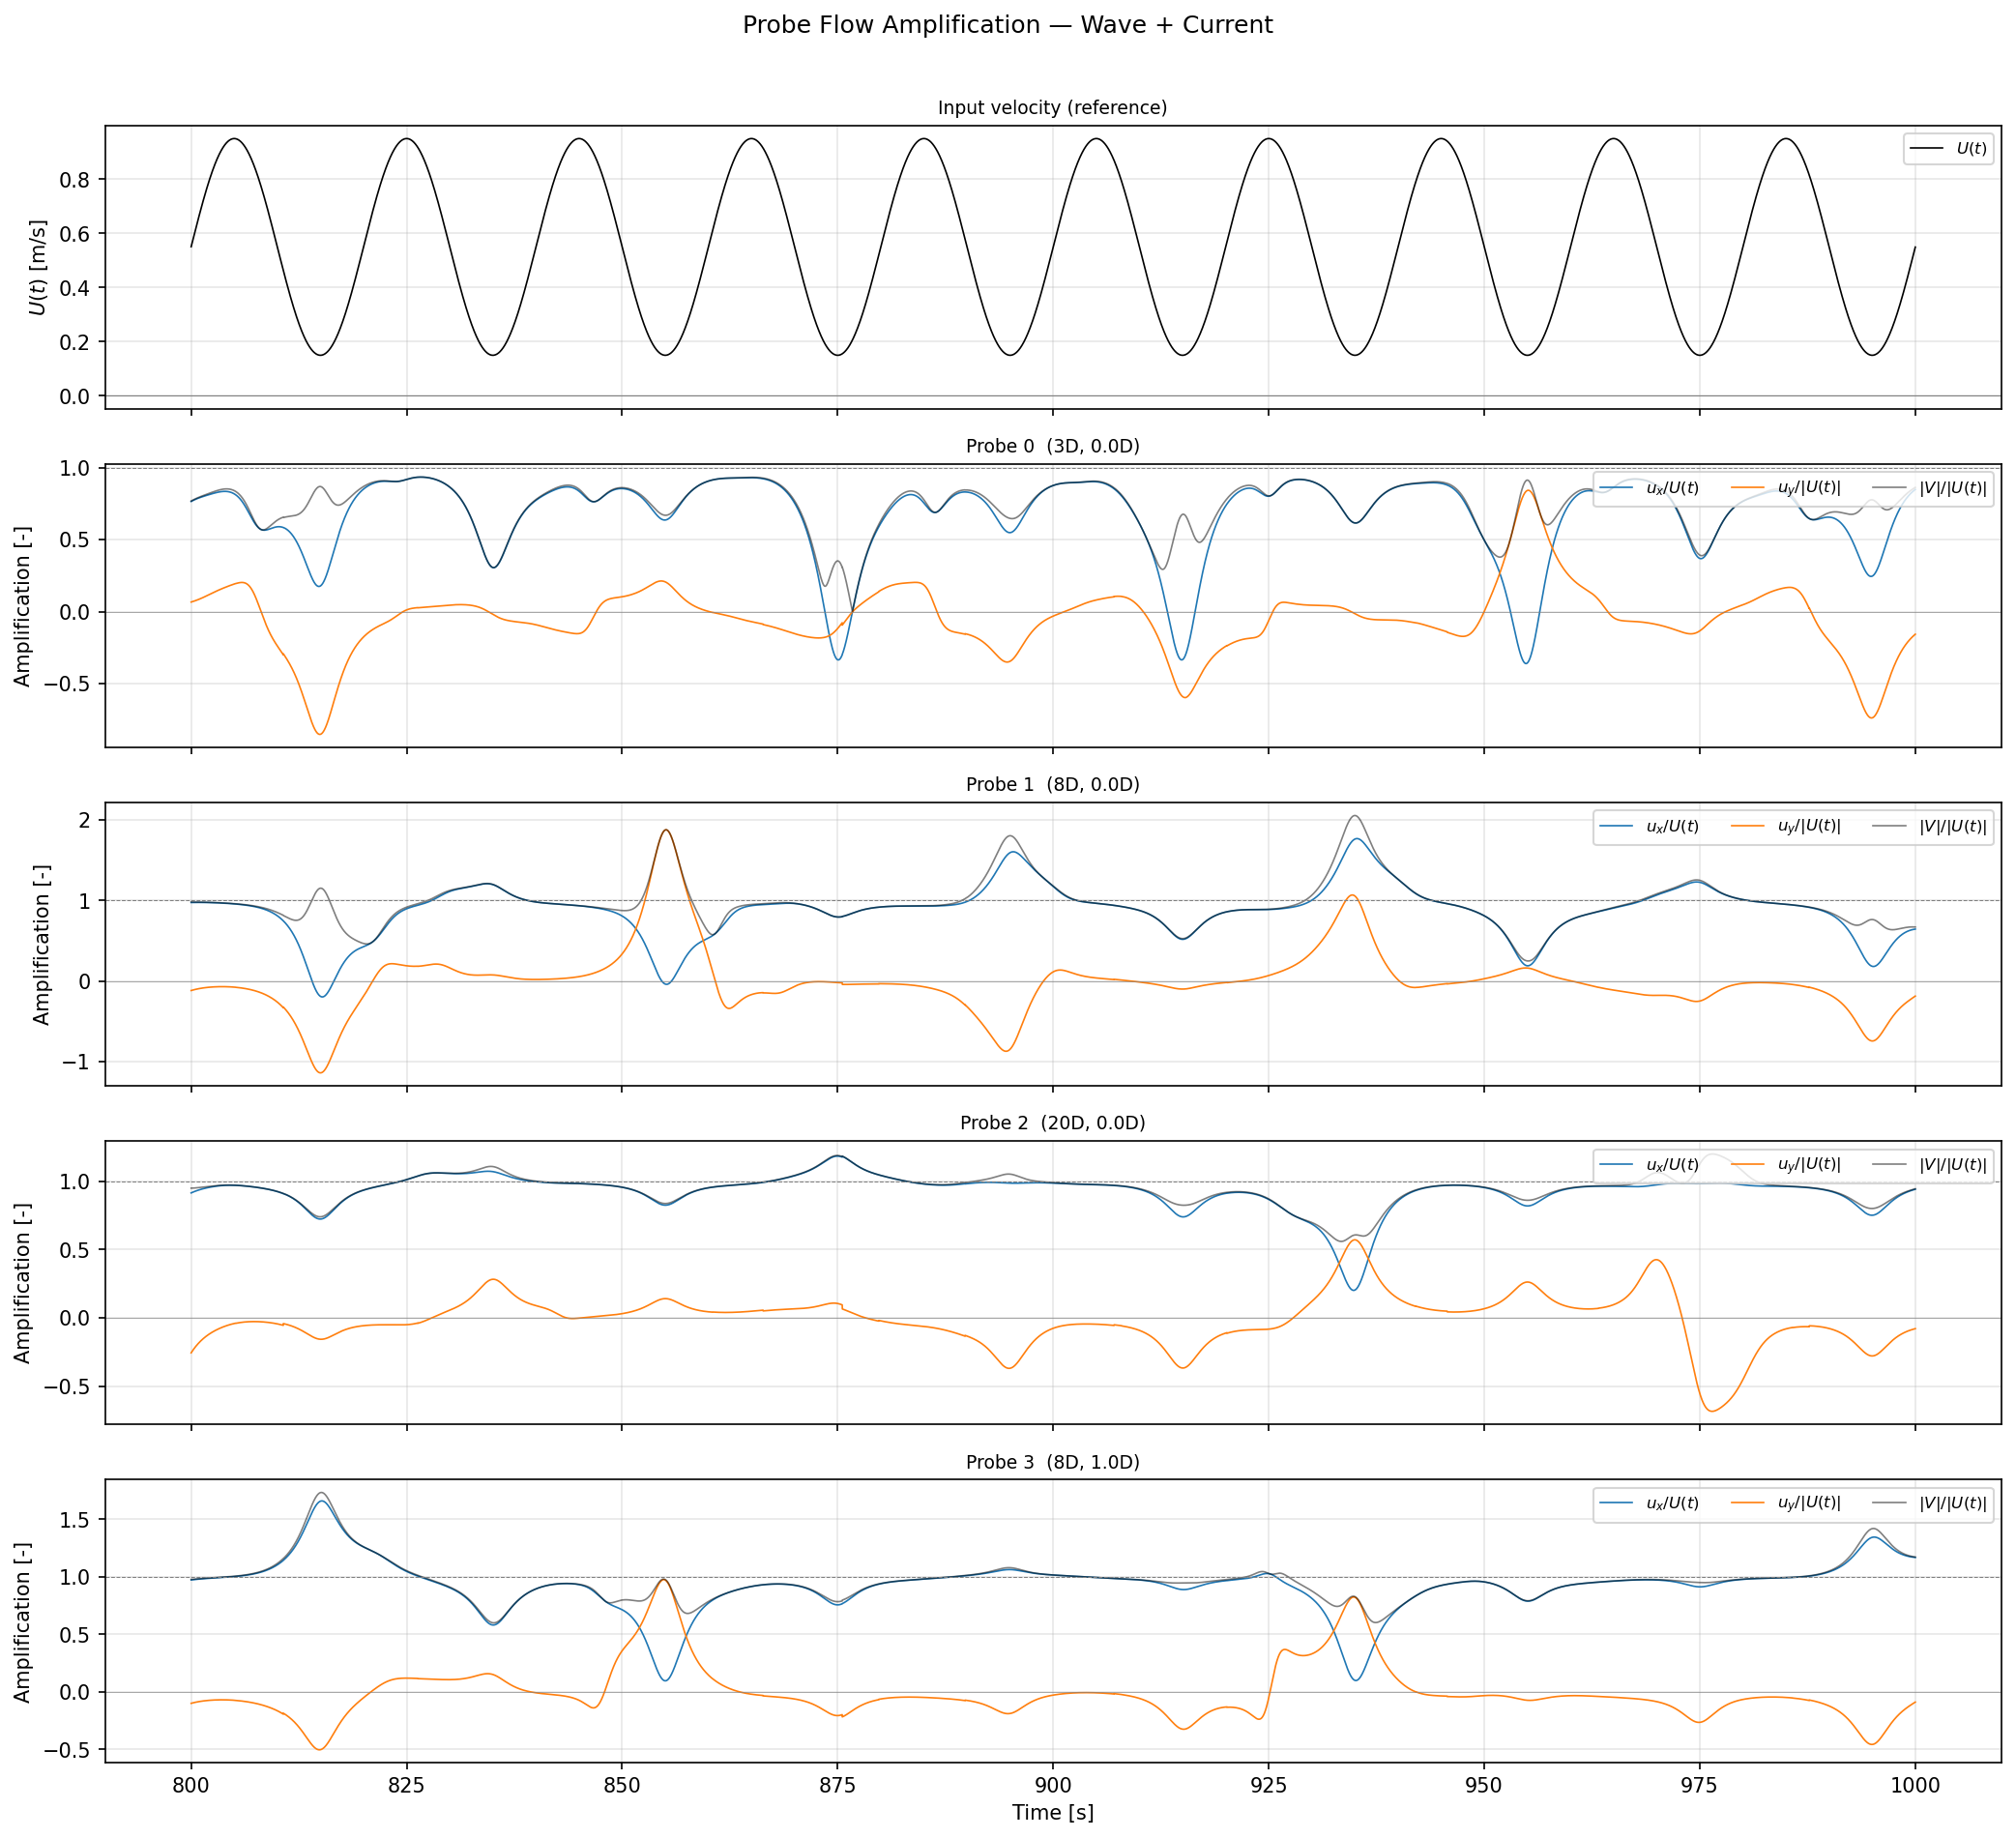

In [10]:
time_arr = results['time'].values
u_inf_arr = results['U_inf'].values

# --- Probe flow amplification time series (last 10 wave cycles) ---
t_start = max(0, TOTAL_TIME - 10 * T_WAVE)
mask = time_arr >= t_start

# Free-field reference: U_inf is purely in x, so free-field = (U_inf, 0)
# Clip small |U_inf| to avoid division spikes near flow reversal
U_ref = u_inf_arr[mask].copy()
U_ref_abs = np.abs(U_ref)
U_ref_abs_safe = np.where(U_ref_abs < 0.05 * U_PEAK, np.nan, U_ref_abs)
U_ref_safe = np.where(U_ref_abs < 0.05 * U_PEAK, np.nan, U_ref)

fig, axes = plt.subplots(len(measurement_points) + 1, 1,
                         figsize=(14, 2.5 * (len(measurement_points) + 1)), sharex=True)

# Top panel: input velocity for reference
axes[0].plot(time_arr[mask], u_inf_arr[mask], 'k-', lw=0.8, label='$U(t)$')
axes[0].axhline(0, color='gray', ls='-', lw=0.5)
axes[0].set_ylabel('$U(t)$ [m/s]')
axes[0].set_title('Input velocity (reference)', fontsize=9)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot flow amplification (u_x/U, u_y/|U|, |V|/|U|) at each probe location
for i, (px, py) in enumerate(measurement_points):
    ax = axes[i + 1]
    ux = results[f'probe_{i}_ux'].values[mask]
    uy = results[f'probe_{i}_uy'].values[mask]
    vmag = results[f'probe_{i}_vmag'].values[mask]

    # Amplification factors
    ux_amp = ux / U_ref_safe          # streamwise: should be ~1.0 far from cylinder
    uy_amp = uy / U_ref_abs_safe      # transverse: normalised by |U|, free-field = 0
    vmag_amp = vmag / U_ref_abs_safe  # total: should be ~1.0 far from cylinder

    ax.plot(time_arr[mask], ux_amp,   lw=0.8, label='$u_x / U(t)$')
    ax.plot(time_arr[mask], uy_amp,   lw=0.8, label='$u_y / |U(t)|$')
    ax.plot(time_arr[mask], vmag_amp, lw=0.8, label='$|V| / |U(t)|$', color='k', alpha=0.5)
    ax.axhline(1.0, color='gray', ls='--', lw=0.5)
    ax.axhline(0.0, color='gray', ls='-', lw=0.3)

    ax.set_ylabel('Amplification [-]')
    ax.set_title(f'Probe {i}  ({px/D:.0f}D, {py/D:.1f}D)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('Probe Flow Amplification — Wave + Current', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/probe_flow_amplification.png', bbox_inches='tight')
plt.show()

## Vorticity Field

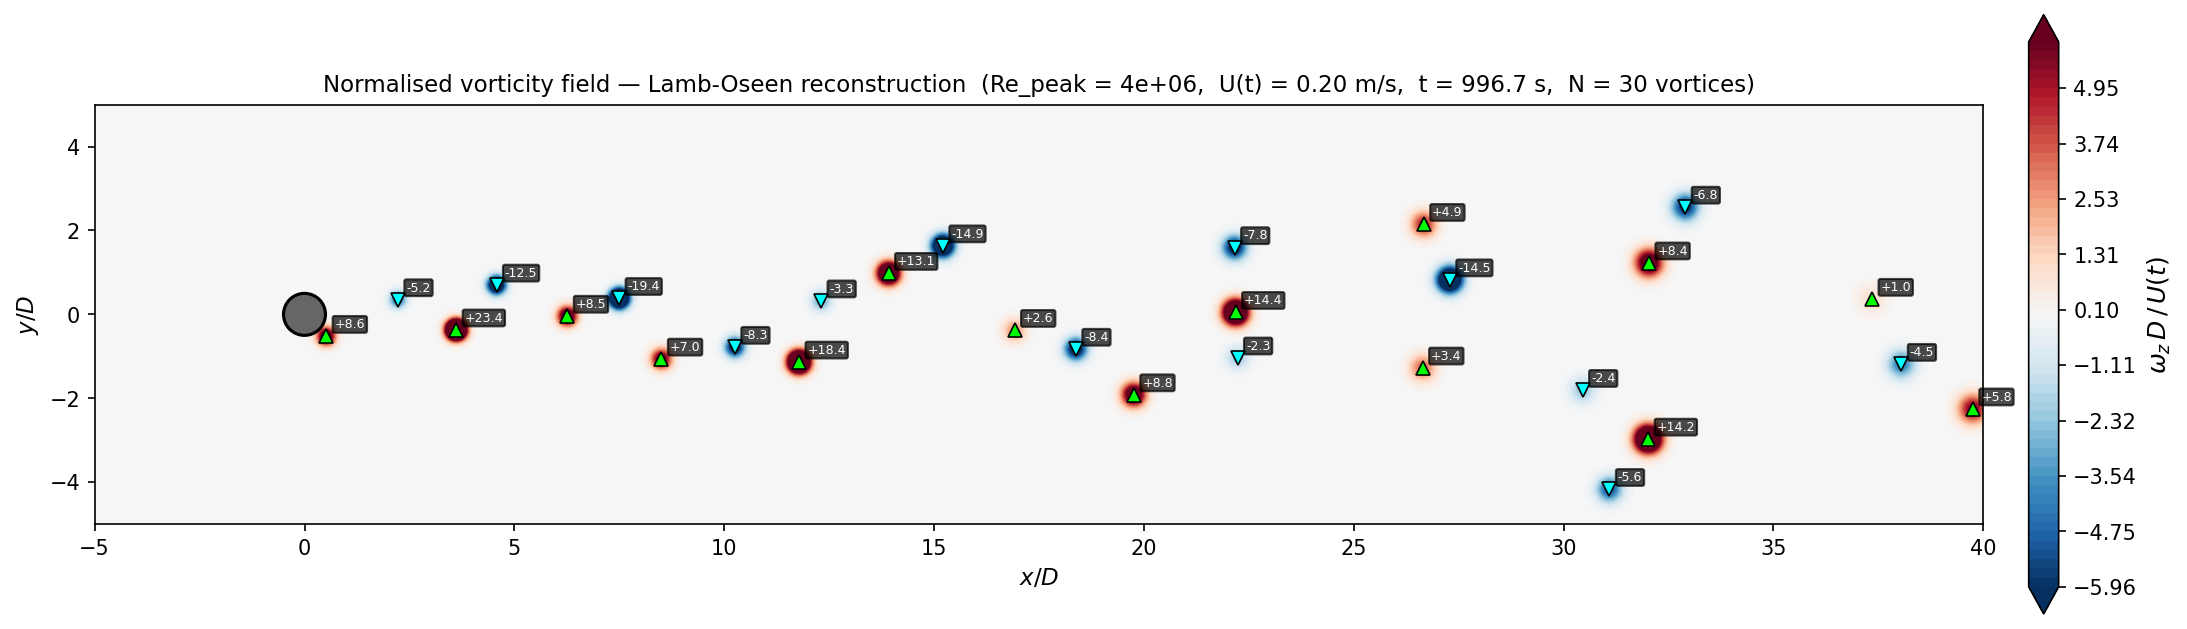

In [11]:
# Vorticity from Lamb-Oseen analytical formula: omega = (Gamma / pi*sigma^2) * exp(-r^2/sigma^2)

nx_fine, ny_fine = 800, 200
x_fine = np.linspace(X_MIN, X_MAX, nx_fine)
y_fine = np.linspace(Y_MIN, Y_MAX, ny_fine)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine)

vm_vorticity = np.zeros_like(X_fine)
for v in vortex_field:
    r2 = (X_fine - v['x'])**2 + (Y_fine - v['y'])**2
    sigma2 = v['sigma']**2
    vm_vorticity += (v['gamma'] / (np.pi * sigma2)) * np.exp(-r2 / sigma2)

# Normalise: omega* = omega * D / U(t)
omega_star = vm_vorticity * D / U_snap

# Linear symmetric colorbar
omega_lim = np.percentile(np.abs(omega_star), 99.5)
levels = np.linspace(-omega_lim, omega_lim, 60)

fig, ax = plt.subplots(figsize=(16, 5))
cf = ax.contourf(X_fine / D, Y_fine / D, omega_star, levels=levels,
                 cmap='RdBu_r', extend='both')
cbar = plt.colorbar(cf, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label(r'$\omega_z \, D \, / \, U(t)$', fontsize=12)

# Mark vortex cores
for v in vortex_field:
    marker = '^' if v['gamma'] > 0 else 'v'
    color = 'lime' if v['gamma'] > 0 else 'cyan'
    omega_peak = v['gamma'] / (np.pi * v['sigma']**2) * D / U_snap
    ax.plot(v['x'] / D, v['y'] / D, marker, color=color, ms=7,
            markeredgecolor='black', markeredgewidth=0.8, zorder=10)
    ax.annotate(f'{omega_peak:+.1f}', (v['x'] / D, v['y'] / D),
                xytext=(4, 4), textcoords='offset points', fontsize=6, color='white',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.7),
                zorder=11)

ax.add_patch(Circle((0, 0), 0.5, color='0.4', ec='k', lw=1.5, zorder=10))
ax.set_xlim(X_MIN / D, X_MAX / D)
ax.set_ylim(Y_MIN / D, Y_MAX / D)
ax.set_xlabel('$x / D$', fontsize=11)
ax.set_ylabel('$y / D$', fontsize=11)
ax.set_title(f'Normalised vorticity field — Lamb-Oseen reconstruction  '
             f'(Re_peak = {RE_PEAK:.0e},  U(t) = {U_snap:.2f} m/s,  t = {snap_time:.1f} s,  N = {len(vortex_field)} vortices)',
             fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/vorticity_field.png', dpi=300, bbox_inches='tight')
plt.show()

## Animation

In [12]:
# from plotting import create_animation

# flow_params = {
#     'rotation_angle': 0.0,
#     'flow_angle': 0.0,
# }

# plot_config = {
#     'x_range': (-2 * D, 20 * D),
#     'y_range': (-4 * D, 4 * D),
#     'grid_size': 400,
#     'arrow_skip': 6,
# }

# create_animation(
#     results_df=results,
#     cylinders=cylinders,
#     flow_params=flow_params,
#     plot_config=plot_config,
#     output_file='wake_wave_current.mp4',
#     frame_skip=1,
#     sample_frames=30,
#     cleanup_frames=True,
#     fps=10,
#     output_dir=OUTPUT_DIR,
# )